# Atera breast cancer Landscape + Clustergram + Enrich

<div data-celldega-wide-notebook></div>

This tutorial uses the released `celldega` package (no autoreload
or widget hot-module reloading). It demonstrates the handoff from a precomputed
Scanpy analysis to Celldega: the default path reuses Scanpy's normalized expression,
UMAP coordinates, and Leiden labels, then uses Celldega to calculate set signatures,
marker-ranked views, an all-gene hierarchy, and linked interactive widgets.
Set `run_clustering = True` only when you want to reproduce the upstream Scanpy
filtering, normalization, PCA, neighbors, UMAP, and Leiden steps from the raw 10x file.

Data source: [broadinstitute/Celldega_Supporting_Data](https://huggingface.co/datasets/broadinstitute/Celldega_Supporting_Data).
Downloads use a direct Hugging Face `/resolve/main/` URL through Python's standard
library, so `huggingface_hub` is not a notebook dependency.


In [1]:
from importlib.metadata import version
from pathlib import Path
import shutil
from urllib.error import HTTPError
from urllib.request import Request, urlopen
import warnings

import celldega as dega
from pandas.errors import PerformanceWarning
import scanpy as sc

print(f"celldega {version('celldega')}")
print(f"scanpy {version('scanpy')}")

celldega 0.25.1
scanpy 1.10.4


## Configuration

The local clustered file is currently the stand-in for the precomputed file being
uploaded to Hugging Face. No download occurs when that file already exists.


In [2]:
run_clustering = False

HF_RESOLVE_BASE = (
    "https://huggingface.co/datasets/"
    "broadinstitute/Celldega_Supporting_Data/resolve/main"
)
RAW_REMOTE_FILENAME = "WTA_Preview_FFPE_Breast_Cancer_outs_AnnData.h5"
CLUSTERED_REMOTE_FILENAMES = (
    "WTA_Preview_FFPE_Breast_Cancer_outs_AnnData_clustered.h5",
    "WTA_Preview_FFPE_Breast_Cancer_outs_AnnData_clustered.h5ad",
)

# Locate data whether the kernel starts in the repository or beside a downloaded notebook.
working_dir = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (working_dir, *working_dir.parents)
        if (candidate / "pyproject.toml").is_file()
        and (candidate / "notebooks").is_dir()
    ),
    None,
)
data_dir = (
    project_root / "notebooks" / "data" / "atera_preview_data_AnnDatas"
    if project_root is not None
    else working_dir / "data" / "atera_preview_data_AnnDatas"
)
raw_path = data_dir / RAW_REMOTE_FILENAME
clustered_path = data_dir / "WTA_Preview_FFPE_Breast_Cancer_outs_AnnData_clustered.h5ad"
set_collection_path = data_dir / "Atera_leiden_SetCollection.h5mu"

In [3]:
def download_if_missing(remote_filename, destination):
    """Download one public Hub file atomically, with no HF client dependency."""
    destination = Path(destination)
    if destination.is_file():
        print(f"Using existing {destination}")
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    partial = destination.with_name(f"{destination.name}.part")
    url = f"{HF_RESOLVE_BASE}/{remote_filename}?download=true"
    request = Request(url, headers={"User-Agent": "celldega-example-notebook"})
    print(f"Downloading {url}")

    try:
        with urlopen(request) as response, partial.open("wb") as output:
            shutil.copyfileobj(response, output, length=8 * 1024 * 1024)
        partial.replace(destination)
    except Exception:
        partial.unlink(missing_ok=True)
        raise

    print(f"Saved {destination}")
    return destination


def download_first_available(remote_filenames, destination):
    if Path(destination).is_file():
        print(f"Using existing {destination}")
        return Path(destination)

    missing = []
    for remote_filename in remote_filenames:
        try:
            return download_if_missing(remote_filename, destination)
        except HTTPError as error:
            if error.code != 404:
                raise
            missing.append(remote_filename)

    raise FileNotFoundError(
        "The precomputed clustering is not on Hugging Face yet. Tried: "
        f"{missing}. Set run_clustering=True to build it from the raw file."
    )

## Load or compute the Scanpy clustering

With the default `run_clustering = False`, this section loads the precomputed Scanpy
AnnData and moves directly into Celldega. The optional clustering branch retains all
genes and saves raw counts in `layers["counts"]` before log normalization, so
SetCollection aggregation can use untransformed counts while marker ranking uses
log-normalized `X`.


In [4]:
if run_clustering:
    download_if_missing(RAW_REMOTE_FILENAME, raw_path)
    adata = sc.read_10x_h5(raw_path)
    sc.pp.filter_cells(adata, min_counts=10)
    sc.pp.filter_genes(adata, min_cells=5)
    adata.layers["counts"] = adata.X.copy()

    sc.pp.normalize_total(adata, target_sum=10_000)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata, random_state=0)
    sc.tl.leiden(adata, random_state=0)
    adata.write_h5ad(clustered_path)
    print(f"Saved precomputed clustering to {clustered_path}")
else:
    download_first_available(CLUSTERED_REMOTE_FILENAMES, clustered_path)
    adata = sc.read_h5ad(clustered_path)

if "counts" not in adata.layers:
    raise ValueError(
        "The clustered AnnData needs layers['counts'] so expression signatures "
        "can be calculated from untransformed counts."
    )

adata

Using existing /Users/feni/Documents/celldega/notebooks/data/atera_preview_data_AnnDatas/WTA_Preview_FFPE_Breast_Cancer_outs_AnnData_clustered.h5ad


AnnData object with n_obs × n_vars = 170022 × 18028
    obs: 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

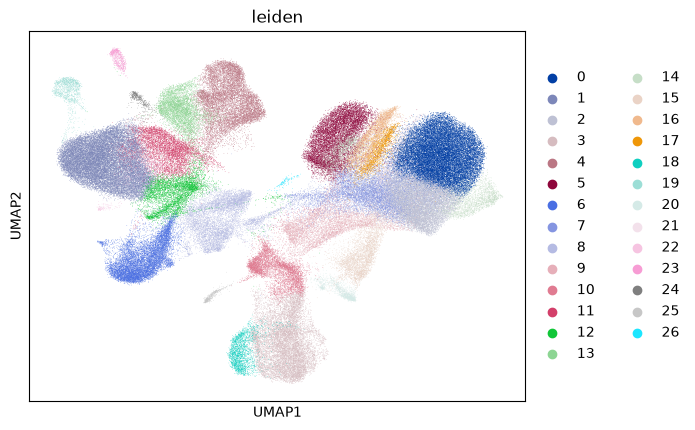

In [5]:
sc.pl.umap(adata, color="leiden")

## Landscape

In [6]:
base_url = (
    "https://raw.githubusercontent.com/cornhundred/"
    "DegaFiles_WTA_Preview_FFPE_Breast_Cancer_outs/main"
)

landscape = dega.viz.Landscape(
    technology="Xenium",
    base_url=base_url,
    height=650,
    adata=adata,
)

## SetCollection expression, fraction expressing, and marker ranks

`expression.X` is the log1p-CPM pseudobulk signature.
`expression.layers["fraction_expressing"]` is the dot-size channel. Marker ranks
are calculated from log-normalized cell-level `adata.X` and persist in the
SetCollection's expression modality.


In [7]:
setc = dega.SetCollection(adata, set_col="leiden", name="leiden")

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=PerformanceWarning,
        module=r"scanpy\.tools\._rank_genes_groups",
    )
    setc.calc_signature(
        adata,
        modality_name="expression",
        layer="counts",
        aggregate="sum",
        normalization="log1p_cpm",
        fraction_expressing_layer="fraction_expressing",
        rank_genes_groups=True,
        rank_genes_groups_layer="X",
        rank_genes_groups_kwargs={"method": "t-test"},
    )

setc.write(set_collection_path)
setc.mod["expression"]

AnnData object with n_obs × n_vars = 27 × 18028
    obs: 'leiden', 'n_cells', 'set_source', 'color'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'gene', 'entity_type'
    uns: 'feature_type', 'aggregate', 'normalization', 'layer', 'expr_threshold', 'fraction_expressing_layer', 'rank_genes_groups', 'axis_entities'
    layers: 'fraction_expressing'

## Clustergram over all genes

The full expression matrix is hierarchically clustered. Marker-ranked views are
additional slider levels; they do not replace or prefilter the all-gene matrix.


In [8]:
marker_levels = [1, 2, 3, 5, 10, 25, 50, 75]

mat = dega.clust.Matrix(
    collection=setc,
    color_by="expression",
    size_by_layer="fraction_expressing",
)

# Transform only the Matrix copy; the persisted SetCollection remains unchanged.
mat.norm("row", by="zscore")
mat.cluster(view="rank_genes_groups", levels=marker_levels)

cgm = dega.viz.Clustergram(
    matrix=mat,
    width=500,
    height=500,
    manual_col_cat="cell_type",
    manual_row_cat="info",
    rank_dim=3,
)

## Linked Landscape, Clustergram, and Enrich

In [9]:
linked_widgets = dega.viz.spatial_clustergram(
    landscape,
    cgm,
    enrich=True,
)

In [10]:
linked_widgets